# Q1 Instantaneous-Basis Static and Oscillating Field Comparison

This notebook compares the new instantaneous-basis interpolated effective model for `transitions.Q1_F1_1o2_F0` against the exact field-diagonalized compact reduced model at static fields, then uses the instantaneous model for an oscillating field with the gauge term included.

In [1]:
from importlib.machinery import SourceFileLoader
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from centrex_tlf import couplings, transitions

runtime_relpath = Path(
    "examples/effective hamiltonian/effective_hamiltonian_runtime.py"
)
repo_root = next(
    (
        candidate
        for candidate in [Path.cwd(), *Path.cwd().parents]
        if (candidate / runtime_relpath).exists()
    ),
    None,
)
if repo_root is None:
    raise FileNotFoundError(runtime_relpath)

ehr = SourceFileLoader(
    "ehr",
    str(repo_root / runtime_relpath),
).load_module()

In [2]:
TRANSITION = transitions.Q1_F1_1o2_F0
OPTICAL_POLARIZATION = couplings.polarization_Z
B_FIELD = (0.0, 0.0, 1e-5)
PATCH_POINTS_VCM = [float(round(val, 1)) for val in np.linspace(0, 15, 31)] + [
    16.0,
    17.0,
    18.0,
    19.0,
    20.0,
    21.0,
    22.0,
    23.0,
    25.0,
    30.0,
    40.0,
    50.0,
    75.0,
    100.0,
]
MASTER_FIELD_VCM = 0.0

RABI_RATE = 2.0 * np.pi * 1e6
DETUNING = 0.0
T_FINAL = 10e-6
N_T = 400
T_EVAL = np.linspace(0.0, T_FINAL, N_T)

OSC_AMPLITUDE_VCM = 25.0
OSC_FREQUENCY_HZ = 100e3
OSC_OMEGA = 2.0 * np.pi * OSC_FREQUENCY_HZ

In [3]:
instantaneous_model = ehr.prepare_instantaneous_interpolated_effective_model(
    field_points=PATCH_POINTS_VCM,
    transition=TRANSITION,
    optical_polarization=OPTICAL_POLARIZATION,
    magnetic_field=B_FIELD,
    master_field=MASTER_FIELD_VCM,
)

(
    instantaneous_model.n_effective_states,
    instantaneous_model.ground_indices.tolist(),
    instantaneous_model.sink_indices.tolist(),
    instantaneous_model.excited_indices.tolist(),
)

(15, [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11], [12, 13], [14])

In [4]:
def bright_ground_index(bundle):
    return int(ehr._optically_bright_ground_index(bundle, bundle.excited_indices))


def rho0_from_index(n_states, index):
    rho0 = np.zeros((n_states, n_states), dtype=np.complex128)
    rho0[index, index] = 1.0
    return rho0


def tracked_exact_bundle(field_vcm):
    _, _, bundle = ehr._tracked_exact_compact_bundle_for_field(
        instantaneous_model, (0.0, 0.0, field_vcm)
    )
    return bundle


def static_compact_case(field_vcm):
    system, bundle = ehr.build_compact_reference_decomposed_bundle(
        transition=TRANSITION,
        optical_polarization=OPTICAL_POLARIZATION,
        electric_field=(0.0, 0.0, field_vcm),
        magnetic_field=B_FIELD,
    )
    rho0 = rho0_from_index(bundle.h_internal.shape[0], bright_ground_index(bundle))
    sol = ehr.solve_static_density_matrix_bundle(
        bundle,
        rho0=rho0,
        t_span=(0.0, T_FINAL),
        rabi_rate=RABI_RATE,
        detuning=DETUNING,
        t_eval=T_EVAL,
    )
    rho_t = ehr.solution_to_density_matrices(sol, bundle.h_internal.shape[0])
    jump_rate = bundle.jump_rate_operator()
    rate_t = ehr.scattering_signal(rho_t, jump_rate)
    photons = ehr.integrated_scattering_probability(T_EVAL, rho_t, jump_rate)
    return dict(
        system=system,
        bundle=bundle,
        solution=sol,
        rho_t=rho_t,
        rate_t=rate_t,
        photons=photons,
    )


def static_instantaneous_case(field_vcm):
    bundle = instantaneous_model.effective_bundle(
        field_vcm, electric_field_derivative=0.0
    )
    rho0 = ehr.default_effective_density_matrix(instantaneous_model)
    sol = ehr.solve_static_instantaneous_interpolated_model(
        instantaneous_model,
        electric_field=field_vcm,
        magnetic_field=B_FIELD,
        rho0=rho0,
        t_span=(0.0, T_FINAL),
        rabi_rate=RABI_RATE,
        detuning=DETUNING,
        t_eval=T_EVAL,
    )
    rho_t = ehr.solution_to_density_matrices(sol, bundle.h_internal.shape[0])
    jump_rate = bundle.jump_rate_operator()
    rate_t = ehr.scattering_signal(rho_t, jump_rate)
    photons = ehr.integrated_scattering_probability(T_EVAL, rho_t, jump_rate)
    return dict(
        bundle=bundle, solution=sol, rho_t=rho_t, rate_t=rate_t, photons=photons
    )


def oscillating_field(t):
    return (0.0, 0.0, OSC_AMPLITUDE_VCM * (1.0 - np.cos(OSC_OMEGA * t)))


def oscillating_field_dot(t):
    return (0.0, 0.0, OSC_AMPLITUDE_VCM * OSC_OMEGA * np.sin(OSC_OMEGA * t))


def time_dependent_scattering_signal(solution, model):
    rho_t = ehr.solution_to_density_matrices(solution, model.n_effective_states)
    rate_t = np.empty(solution.t.size, dtype=np.float64)
    for idx, (t, rho) in enumerate(zip(solution.t, rho_t)):
        bundle = model.effective_bundle(
            oscillating_field(t),
            electric_field_derivative=oscillating_field_dot(t),
        )
        rate_t[idx] = np.real(np.trace(rho @ bundle.jump_rate_operator()))
    return rho_t, rate_t


def oscillating_instantaneous_case():
    rho0 = ehr.default_effective_density_matrix(instantaneous_model)
    sol = ehr.solve_instantaneous_interpolated_model(
        instantaneous_model,
        electric_field=oscillating_field,
        electric_field_derivative=oscillating_field_dot,
        magnetic_field=B_FIELD,
        rho0=rho0,
        t_span=(0.0, T_FINAL),
        rabi_rate=RABI_RATE,
        detuning=DETUNING,
        t_eval=T_EVAL,
    )
    rho_t, rate_t = time_dependent_scattering_signal(sol, instantaneous_model)
    photons = float(np.trapezoid(rate_t, x=sol.t))
    return dict(solution=sol, rho_t=rho_t, rate_t=rate_t, photons=photons)

In [5]:
static_compact_0 = static_compact_case(0.0)
static_inst_0 = static_instantaneous_case(0.0)
static_compact_100 = static_compact_case(100.0)
static_inst_100 = static_instantaneous_case(100.0)

In [6]:
osc_inst = oscillating_instantaneous_case()

In [7]:
summary = pd.DataFrame(
    [
        {
            "case": "static compact 0 V/cm",
            "photons": static_compact_0["photons"],
        },
        {
            "case": "static instantaneous 0 V/cm",
            "photons": static_inst_0["photons"],
        },
        {
            "case": "static compact 100 V/cm",
            "photons": static_compact_100["photons"],
        },
        {
            "case": "static instantaneous 100 V/cm",
            "photons": static_inst_100["photons"],
        },
        {
            "case": "oscillating instantaneous 0->50 V/cm",
            "photons": osc_inst["photons"],
        },
    ]
)
summary["relative_to_static_compact_0"] = (
    summary["photons"] / static_compact_0["photons"] - 1.0
)
summary

,case,photons,relative_to_static_compact_0
0,static compact 0 V/cm,1.154114,0.000000
1,static instantaneous 0 V/cm,1.154110,-0.000003
2,static compact 100 V/cm,1.482712,0.284718
3,static instantaneous 100 V/cm,1.482712,0.284718
4,oscillating instantaneous 0->50 V/cm,0.949082,-0.177654


In [8]:
tracked_exact_0 = tracked_exact_bundle(0.0)
tracked_exact_100 = tracked_exact_bundle(100.0)

operator_checks = pd.DataFrame(
    [
        {
            "field_vcm": 0.0,
            "h_internal_max_abs_diff": float(
                np.max(
                    np.abs(
                        static_inst_0["bundle"].h_internal - tracked_exact_0.h_internal
                    )
                )
            ),
            "h_opt_max_abs_diff": float(
                np.max(np.abs(static_inst_0["bundle"].h_opt - tracked_exact_0.h_opt))
            ),
            "dissipator_max_abs_diff": float(
                np.max(
                    np.abs(
                        static_inst_0["bundle"].dissipator_superoperator()
                        - tracked_exact_0.dissipator_superoperator()
                    )
                )
            ),
        },
        {
            "field_vcm": 100.0,
            "h_internal_max_abs_diff": float(
                np.max(
                    np.abs(
                        static_inst_100["bundle"].h_internal
                        - tracked_exact_100.h_internal
                    )
                )
            ),
            "h_opt_max_abs_diff": float(
                np.max(
                    np.abs(static_inst_100["bundle"].h_opt - tracked_exact_100.h_opt)
                )
            ),
            "dissipator_max_abs_diff": float(
                np.max(
                    np.abs(
                        static_inst_100["bundle"].dissipator_superoperator()
                        - tracked_exact_100.dissipator_superoperator()
                    )
                )
            ),
        },
    ]
)
operator_checks

,field_vcm,h_internal_max_abs_diff,h_opt_max_abs_diff,dissipator_max_abs_diff
0,0.0,0.0,0.0,0.0
1,100.0,0.0,0.0,0.0


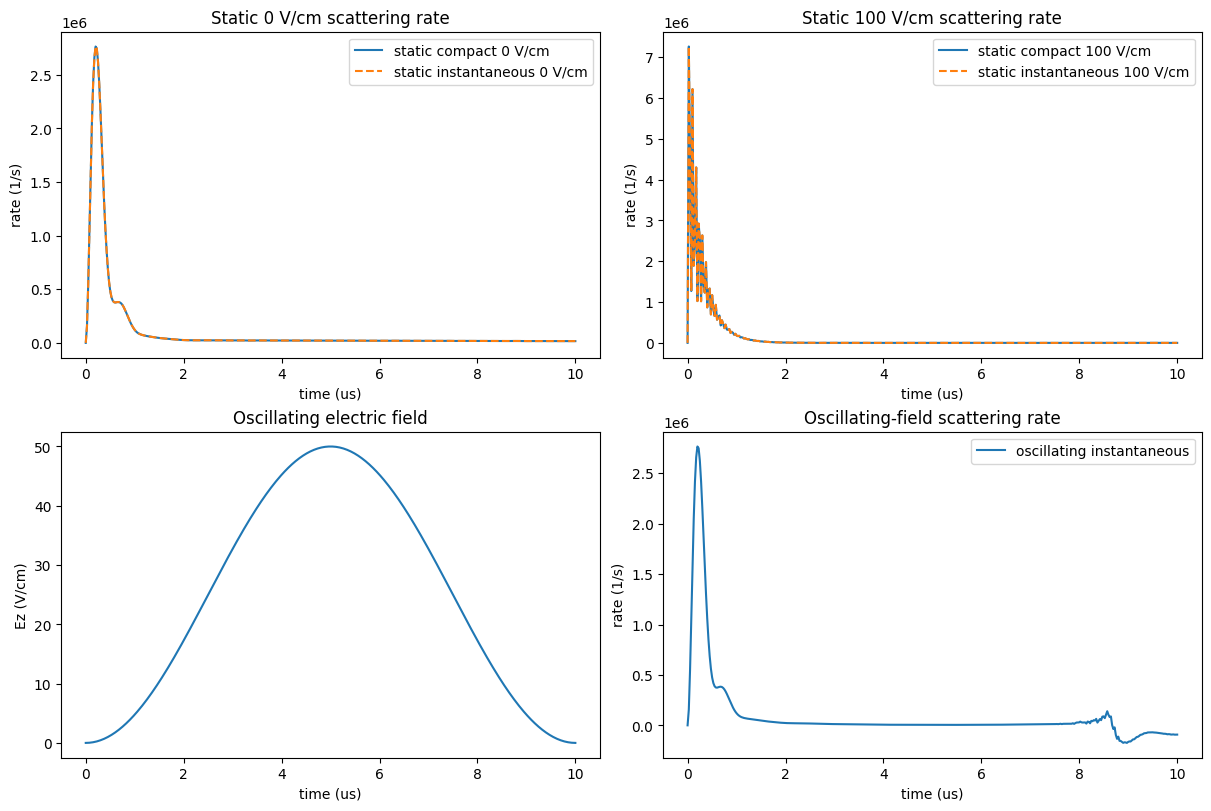

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

t_us = 1e6 * T_EVAL
osc_field = np.array([oscillating_field(t)[2] for t in T_EVAL], dtype=np.float64)

axes[0, 0].plot(t_us, static_compact_0["rate_t"], label="static compact 0 V/cm")
axes[0, 0].plot(
    t_us, static_inst_0["rate_t"], "--", label="static instantaneous 0 V/cm"
)
axes[0, 0].set_title("Static 0 V/cm scattering rate")
axes[0, 0].set_xlabel("time (us)")
axes[0, 0].set_ylabel("rate (1/s)")
axes[0, 0].legend()

axes[0, 1].plot(t_us, static_compact_100["rate_t"], label="static compact 100 V/cm")
axes[0, 1].plot(
    t_us, static_inst_100["rate_t"], "--", label="static instantaneous 100 V/cm"
)
axes[0, 1].set_title("Static 100 V/cm scattering rate")
axes[0, 1].set_xlabel("time (us)")
axes[0, 1].set_ylabel("rate (1/s)")
axes[0, 1].legend()

axes[1, 0].plot(t_us, osc_field)
axes[1, 0].set_title("Oscillating electric field")
axes[1, 0].set_xlabel("time (us)")
axes[1, 0].set_ylabel("Ez (V/cm)")

axes[1, 1].plot(t_us, osc_inst["rate_t"], label="oscillating instantaneous")
axes[1, 1].set_title("Oscillating-field scattering rate")
axes[1, 1].set_xlabel("time (us)")
axes[1, 1].set_ylabel("rate (1/s)")
axes[1, 1].legend()

plt.show()

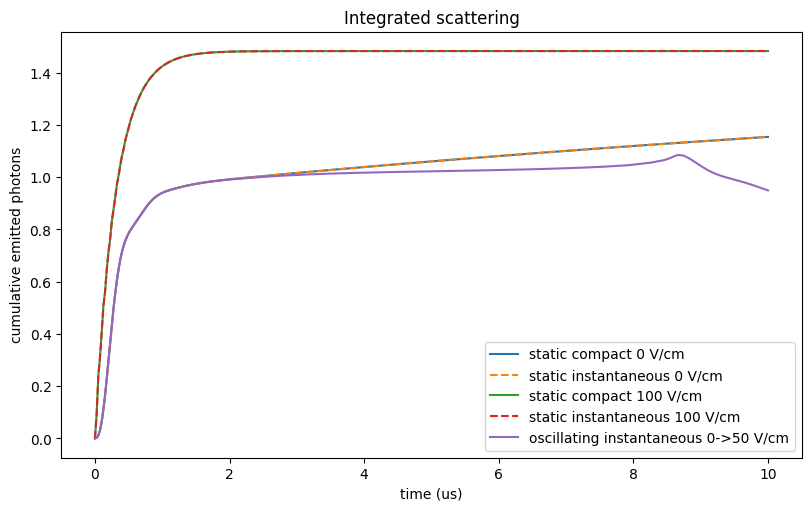

In [10]:
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)


def cumulative_from_rate(rate_t):
    return np.concatenate(
        [[0.0], np.cumulative_sum(0.5 * (rate_t[1:] + rate_t[:-1]) * np.diff(T_EVAL))]
    )


ax.plot(
    1e6 * T_EVAL,
    cumulative_from_rate(static_compact_0["rate_t"]),
    label="static compact 0 V/cm",
)
ax.plot(
    1e6 * T_EVAL,
    cumulative_from_rate(static_inst_0["rate_t"]),
    "--",
    label="static instantaneous 0 V/cm",
)
ax.plot(
    1e6 * T_EVAL,
    cumulative_from_rate(static_compact_100["rate_t"]),
    label="static compact 100 V/cm",
)
ax.plot(
    1e6 * T_EVAL,
    cumulative_from_rate(static_inst_100["rate_t"]),
    "--",
    label="static instantaneous 100 V/cm",
)
ax.plot(
    1e6 * T_EVAL,
    cumulative_from_rate(osc_inst["rate_t"]),
    label="oscillating instantaneous 0->50 V/cm",
)
ax.set_xlabel("time (us)")
ax.set_ylabel("cumulative emitted photons")
ax.set_title("Integrated scattering")
ax.legend()
plt.show()

## Moving Basis term

In [11]:
def max_offdiag_abs(matrix):
    matrix = np.asarray(matrix, dtype=np.complex128)
    off = matrix.copy()
    np.fill_diagonal(off, 0.0)
    return float(np.max(np.abs(off)))


def fro_norm(matrix):
    return float(np.linalg.norm(np.asarray(matrix, dtype=np.complex128)))


E_scan = np.linspace(0.0, 50.0, 400)

A_norm = []
A_offdiag = []
Hg_norm = []
Hg_offdiag = []
Hinst_norm = []
Hinst_offdiag = []
Hdrive_norm = []

for E in E_scan:
    bundle_static = instantaneous_model.effective_bundle(
        E,
        electric_field_derivative=0.0,
    )
    bundle_dynamic = instantaneous_model.effective_bundle(
        E,
        electric_field_derivative=(0.0, 0.0, OSC_AMPLITUDE_VCM * OSC_OMEGA),
    )

    H_inst = np.asarray(bundle_static.h_internal)
    H_drive = 0.5 * RABI_RATE * np.asarray(bundle_static.h_opt)

    # Since h_internal(dynamic) = h_internal(static) - E_dot * A(E),
    # extract A(E) by finite difference in E_dot.
    E_dot_test = OSC_AMPLITUDE_VCM * OSC_OMEGA
    H_gauge = np.asarray(bundle_dynamic.h_internal) - H_inst
    A_E = -H_gauge / E_dot_test

    A_norm.append(fro_norm(A_E))
    A_offdiag.append(max_offdiag_abs(A_E))
    Hg_norm.append(fro_norm(H_gauge))
    Hg_offdiag.append(max_offdiag_abs(H_gauge))
    Hinst_norm.append(fro_norm(H_inst))
    Hinst_offdiag.append(max_offdiag_abs(H_inst))
    Hdrive_norm.append(fro_norm(H_drive))

A_norm = np.array(A_norm)
A_offdiag = np.array(A_offdiag)
Hg_norm = np.array(Hg_norm)
Hg_offdiag = np.array(Hg_offdiag)
Hinst_norm = np.array(Hinst_norm)
Hinst_offdiag = np.array(Hinst_offdiag)
Hdrive_norm = np.array(Hdrive_norm)


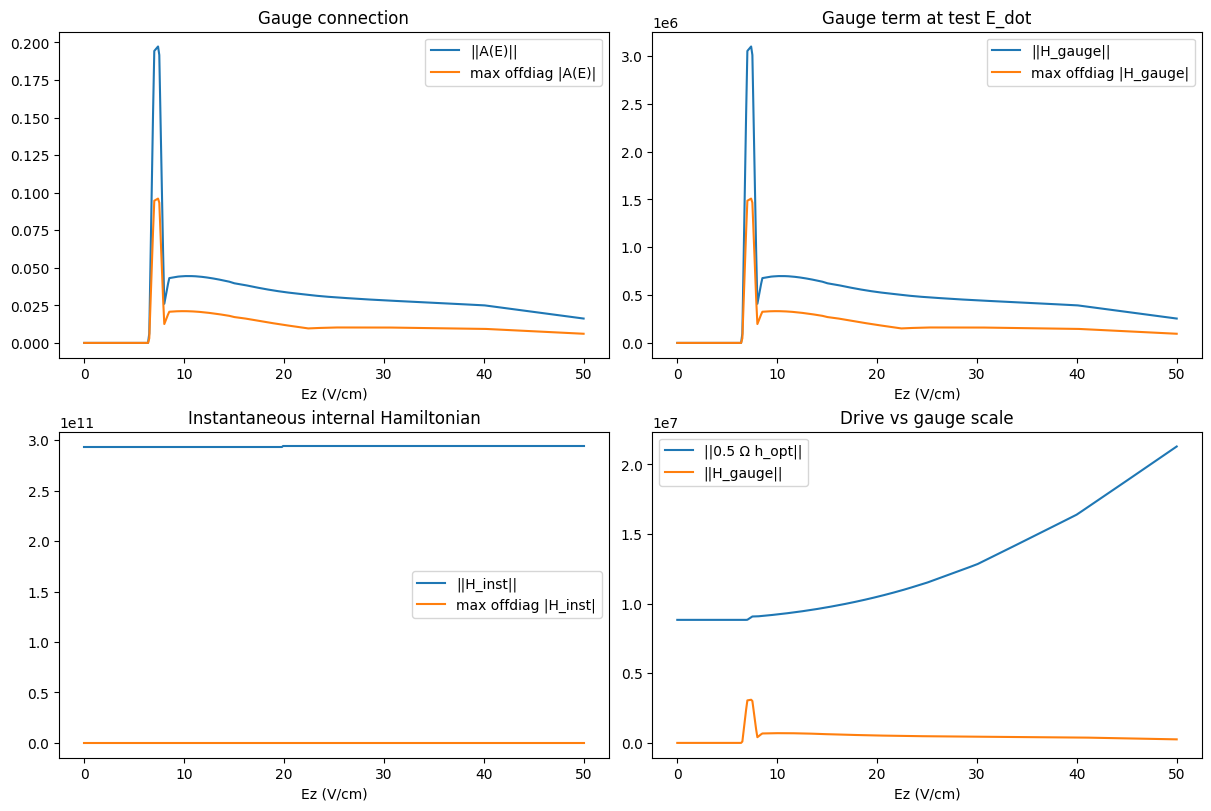

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

axes[0, 0].plot(E_scan, A_norm, label="||A(E)||")
axes[0, 0].plot(E_scan, A_offdiag, label="max offdiag |A(E)|")
axes[0, 0].set_title("Gauge connection")
axes[0, 0].set_xlabel("Ez (V/cm)")
axes[0, 0].legend()

axes[0, 1].plot(E_scan, Hg_norm, label="||H_gauge||")
axes[0, 1].plot(E_scan, Hg_offdiag, label="max offdiag |H_gauge|")
axes[0, 1].set_title("Gauge term at test E_dot")
axes[0, 1].set_xlabel("Ez (V/cm)")
axes[0, 1].legend()

axes[1, 0].plot(E_scan, Hinst_norm, label="||H_inst||")
axes[1, 0].plot(E_scan, Hinst_offdiag, label="max offdiag |H_inst|")
axes[1, 0].set_title("Instantaneous internal Hamiltonian")
axes[1, 0].set_xlabel("Ez (V/cm)")
axes[1, 0].legend()

axes[1, 1].plot(E_scan, Hdrive_norm, label="||0.5 Ω h_opt||")
axes[1, 1].plot(E_scan, Hg_norm, label="||H_gauge||")
axes[1, 1].set_title("Drive vs gauge scale")
axes[1, 1].set_xlabel("Ez (V/cm)")
axes[1, 1].legend()

plt.show()


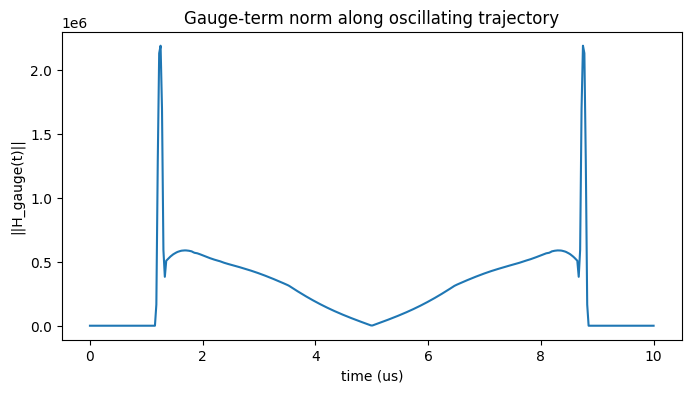

In [13]:
t_probe = T_EVAL
E_t = np.array([oscillating_field(t)[2] for t in t_probe])
Edot_t = np.array([oscillating_field_dot(t)[2] for t in t_probe])

Hg_actual_norm = []
for E, Edot in zip(E_t, Edot_t):
    b0 = instantaneous_model.effective_bundle(E, electric_field_derivative=0.0)
    b1 = instantaneous_model.effective_bundle(
        E, electric_field_derivative=(0.0, 0.0, Edot)
    )
    Hg = np.asarray(b1.h_internal) - np.asarray(b0.h_internal)
    Hg_actual_norm.append(fro_norm(Hg))

Hg_actual_norm = np.array(Hg_actual_norm)

plt.figure(figsize=(8, 4))
plt.plot(1e6 * t_probe, Hg_actual_norm)
plt.xlabel("time (us)")
plt.ylabel("||H_gauge(t)||")
plt.title("Gauge-term norm along oscillating trajectory")
plt.show()
